In [1]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import linregress, pearsonr
import time
import pickle

import sys
import os

# Get the current working directory (where the script is run from)
current_dir = os.getcwd()

# Get the parent directory
parent_dir = os.path.dirname(current_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from nsm.nsm import *

params = {
    'figure.figsize': (3, 2.5),       # Figure size in inches
    'figure.dpi': 300,               # Resolution in dots per inch
    'axes.labelsize': 6,            # Font size of the axes labels
    'axes.titlesize': 6,            # Font size of the subplot titles
    'axes.titlepad': 10,             # Spacing between the subplot title and the plot
    'axes.linewidth': .5,           # Width of the axis lines
    'axes.grid': False,              # Display grid lines
    'axes.grid.axis': 'both',        # Display grid lines for both major and minor ticks
    'grid.alpha': 0.5,               # Transparency of the grid lines
    'grid.linewidth': 0.5,           # Width of the grid lines
    'xtick.labelsize': 6,           # Font size of the x-axis tick labels
    'ytick.labelsize': 6,           # Font size of the y-axis tick labels
    'xtick.major.size': 3,           # Length of the major x-axis ticks in points
    'xtick.major.width': .5,        # Width of the major x-axis ticks
    'ytick.major.size': 3,           # Length of the major y-axis ticks in points
    'ytick.major.width': .5,        # Width of the major y-axis ticks
    'xtick.minor.size': 2,           # Length of the minor x-axis ticks in points
    'xtick.minor.width': .5,        # Width of the minor x-axis ticks
    'ytick.minor.size': 2,           # Length of the minor y-axis ticks in points
    'ytick.minor.width': .5,        # Width of the minor y-axis ticks
    'xtick.direction': 'in',         # Direction of the x-axis ticks ('in', 'out', or 'inout')
    'ytick.direction': 'in',         # Direction of the y-axis ticks ('in', 'out', or 'inout')
    'legend.fontsize': 6,           # Font size of the legend
    'legend.frameon': True,          # Whether to draw a frame around the legend
    'legend.facecolor': 'inherit',   # Background color of the legend
    'legend.edgecolor': '0.8',       # Edge color of the legend
    'legend.framealpha': 0.8,        # Transparency of the legend frame
    'legend.loc': 'best',            # Location of the legend ('best', 'upper right', 'upper left', 'lower left', etc.)
    'legend.title_fontsize': 6,     # Font size of the legend title
    'svg.fonttype': 'none'           # Output font type for PDF files
}

plt.rcParams.update(params)

np.random.seed(123)

In [2]:
# import CR data
df = pd.read_csv("Simulated_CR_data.csv").rename(columns={"Experiments":"Treatments"})


In [3]:
df_test = pd.read_csv("Simulated_CR_data_test.csv").rename(columns={"Experiments":"Treatments"})
df_test 

,Treatments,Time,s1,s2,s3,s4,r1,r2,r3,r4,r5,r6
0,Exp_9,0.0,0.010000,0.010000,0.010000,0.010000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000
1,Exp_9,4.0,0.043801,0.052690,0.051924,0.028177,0.870784,0.994493,0.002047,1.046654,0.024773,0.040047
2,Exp_9,8.0,0.130449,0.180045,0.213622,0.070928,0.505306,0.936982,0.008206,1.173180,0.101296,0.183902
3,Exp_9,12.0,0.203054,0.297087,0.538569,0.145125,0.136283,0.662847,0.014121,1.304885,0.248672,0.429083
4,Exp_9,16.0,0.216204,0.320087,0.820952,0.247416,0.019470,0.301464,0.015742,1.376954,0.408915,0.583438
5,Exp_9,20.0,0.211064,0.312856,0.935871,0.370521,0.002044,0.101854,0.015951,1.436135,0.541846,0.562677
6,Exp_9,24.0,0.203736,0.301944,0.951795,0.496525,0.000191,0.029969,0.015972,1.495578,0.653406,0.444595
7,Exp_9,28.0,0.196440,0.291042,0.933478,0.602375,0.000017,0.008299,0.015974,1.548523,0.745106,0.310636
8,Exp_9,32.0,0.189385,0.280501,0.906010,0.674207,0.000001,0.002245,0.015974,1.589087,0.813507,0.200904


In [4]:
species = [c for c in df.columns.values[2:] if 's' in c]
mediators = [c for c in df.columns.values[2:] if 'r' in c]
inputs = []

In [5]:
# Define function to make predictions on test data
def plot_sample(model, comm_data, comm_data_train):

    # make sure comm_data is sorted in chronological order
    comm_data_train.sort_values(by='Time', ascending=True, inplace=True)
    tspan_train = comm_data_train.Time.values

    # pull just the community data
    species_true = comm_data_train[species].values
    mediators_true = comm_data_train[mediators].values
    input_vals = comm_data_train[inputs].values[0]
    output_true_train = np.concatenate((species_true, mediators_true), -1)

    # make sure comm_data is sorted in chronological order
    comm_data.sort_values(by='Time', ascending=True, inplace=True)
    tspan = comm_data.Time.values

    # pull just the community data
    species_true = comm_data[species].values
    mediators_true = comm_data[mediators].values
    input_vals = comm_data[inputs].values[0]
    output_true = np.concatenate((species_true, mediators_true), -1)

    # determine initial condition 
    s0 = species_true[0]
    r0 = mediators_true[0]
    x0 = np.concatenate((s0, r0))
    
    # increase teval
    t_eval = np.linspace(0, tspan[-1] + 2., 100)
    steps = len(t_eval)
    
    # predict at measurement times
    species_pred, mediators_pred = model.predict_point(x0, t_eval, inputs=input_vals)

    # generate posterior samples
    # species_pred, mediators_pred = model.predict_sample(x0, 
    #                                                     t_eval, 
    #                                                     n_sample=50, 
    #                                                     inputs=input_vals)
    
    # # compute summary statistics (mean and variance) of posterior predictive distribution
    E_species_pred, V_species_pred, E_mediators_pred, V_mediators_pred = model.predict(x0, 
                                                                                       t_eval, 
                                                                                       n_sample=100,
                                                                                       inputs=input_vals)

    # E_species_pred, E_mediators_pred = model.predict_point(x0, t_eval, inputs=input_vals)

    # # concatenate species and mediator predictions
    output_pred = np.concatenate((species_pred, mediators_pred), -1)
    E_output_pred = np.concatenate((E_species_pred, E_mediators_pred), -1)
    V_output_pred = np.concatenate((V_species_pred, V_mediators_pred), -1)
    
    # # predict end-point measured values
    # true.append(species_true[-1])
    # pred.append(species_pred[-1])
    # spcs.append(species)

    # plot the results
    color_index = 0
    plt.figure(figsize=(2, 2))
    for i, sp in enumerate(species):
        out_true_train = output_true_train[:,i]
        out_true = output_true[:,i]
        if i > 0:
            plt.scatter(tspan_train, out_true_train, color='C{}'.format(color_index), edgecolor='k', s=20, zorder=2, label=species[i])
            plt.plot(tspan, out_true, color='C{}'.format(color_index), linestyle='--', alpha=.5)

            # # plot posterior samples
            # for out in output_pred:
            #         plt.plot(t_eval, out[:, i], color='C{}'.format(i), alpha=.15, zorder=0)
                    
            # plot posterior predictive as a Gaussian 
            plt.fill_between(t_eval, 
                             E_output_pred[:,i] - V_output_pred[:, i] ** .5, 
                             E_output_pred[:,i] + V_output_pred[:, i] ** .5,  
                             color='C{}'.format(color_index), alpha=0.2)

            # plot mean of posterior 
            plt.plot(t_eval, E_output_pred[:,i], color='C{}'.format(color_index), linewidth=1, zorder=1)
            color_index += 1

    # plt.legend()
    plt.axhline(y=0, linestyle='-', color='k', alpha=.5)
    plt.xlabel("Time (hr)")
    plt.ylabel("Species abundance")
    plt.ylim([0, 1.5])
    plt.title(comm_data_train.Treatments.values[0])
    plt.tight_layout()
    plt.savefig(f"figures/trajectories_sp_{comm_data_train.Treatments.values[0]}.svg")
    plt.show()

    # plot the results
    plt.figure(figsize=(2, 2))
    for i, sp in enumerate(mediators):
        if i in [1, 3, 4]:

            out_true_train = output_true_train[:,len(species)+i]
            out_true = output_true[:,len(species)+i]

            plt.scatter(tspan_train, out_true_train, color='C{}'.format(color_index), edgecolor='k', s=20, zorder=2, label=mediators[i])
            plt.plot(tspan, out_true, color='C{}'.format(color_index), linestyle='--', alpha=.5)

            # # plot posterior samples
            # for out in output_pred:
            #         plt.plot(t_eval, out[:, len(species)+i], color='C{}'.format(4+i), alpha=.15, zorder=0)
                    
            # plot posterior predictive as a Gaussian 
            plt.fill_between(t_eval, 
                            E_output_pred[:,len(species)+i] - V_output_pred[:, len(species)+i] ** .5, 
                            E_output_pred[:,len(species)+i] + V_output_pred[:, len(species)+i] ** .5,  
                            color='C{}'.format(color_index), alpha=0.2)

            # plot mean of posterior 
            plt.plot(t_eval, E_output_pred[:, len(species)+i], color='C{}'.format(color_index), linewidth=1, zorder=1)
            color_index += 1

    # plt.legend()
    plt.axhline(y=0, linestyle='-', color='k', alpha=.5)
    plt.xlabel("Time (hr)")
    plt.ylabel("Metabolite concentration")
    plt.ylim([0, 2])
    plt.title(comm_data_train.Treatments.values[0])
    plt.tight_layout()
    plt.savefig(f"figures/trajectories_mt_{comm_data_train.Treatments.values[0]}.svg")
    plt.show()
        
    # return true_s, pred_s, true_m, pred_m 

In [6]:
# exp_longest = df.Treatments.unique()[2]
# df_train = df.iloc[df.Treatments.values==exp_longest].copy()

# # init model 
# model = NSM(dataframe=df_train, 
#             species=species,
#             mediators=mediators, 
#             inputs=inputs,
#             n_hidden=16, n_layers=1,
#             nu2=.001, sigma2=0.0001, scale=False)

# # init params
# model.init_params(sample=True, alpha_0=.001, z_std_scale=.01)

# print(f"Total parameters: {model.n_params}")
# t0 = time.time()
# model.fit_rmse(epochs=5000)
# model.fit_posterior(lr=1e-3, n_sample=3)
# print("Elapsed time: {:.3f}s".format(time.time()-t0))

# plot_sample(model, df_test, df_train)

Total parameters: 400
Epoch 0, RMSE: 0.054
Epoch 10, RMSE: 0.053
Epoch 20, RMSE: 0.053
Epoch 30, RMSE: 0.052
Epoch 40, RMSE: 0.051
Epoch 50, RMSE: 0.051
Epoch 60, RMSE: 0.050
Epoch 70, RMSE: 0.049
Epoch 80, RMSE: 0.048
Epoch 90, RMSE: 0.047
Epoch 100, RMSE: 0.045
Epoch 110, RMSE: 0.044
Epoch 120, RMSE: 0.042
Epoch 130, RMSE: 0.041
Epoch 140, RMSE: 0.039
Epoch 150, RMSE: 0.037
Epoch 160, RMSE: 0.035
Epoch 170, RMSE: 0.033
Epoch 180, RMSE: 0.031
Epoch 190, RMSE: 0.029
Epoch 200, RMSE: 0.028
Epoch 210, RMSE: 0.027
Epoch 220, RMSE: 0.027
Epoch 230, RMSE: 0.026
Epoch 240, RMSE: 0.026
Epoch 250, RMSE: 0.025
Epoch 260, RMSE: 0.025
Epoch 270, RMSE: 0.024
Epoch 280, RMSE: 0.024
Epoch 290, RMSE: 0.024
Epoch 300, RMSE: 0.023
Epoch 310, RMSE: 0.023
Epoch 320, RMSE: 0.023
Epoch 330, RMSE: 0.022
Epoch 340, RMSE: 0.022
Epoch 350, RMSE: 0.022
Epoch 360, RMSE: 0.021
Epoch 370, RMSE: 0.021
Epoch 380, RMSE: 0.021
Epoch 390, RMSE: 0.020
Epoch 400, RMSE: 0.020
Epoch 410, RMSE: 0.020
Epoch 420, RMSE: 0.019


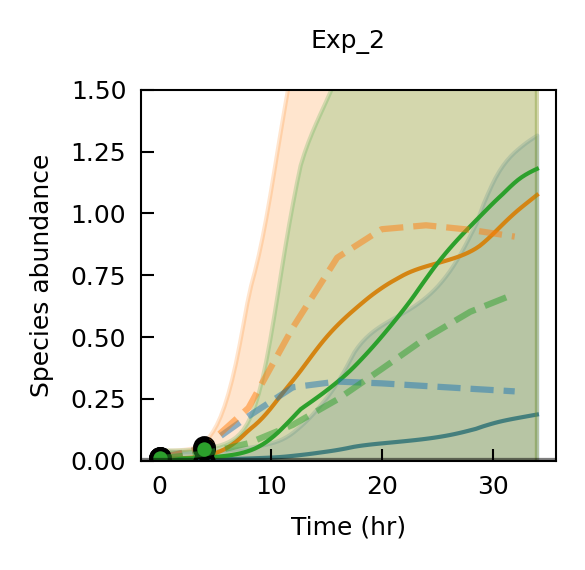

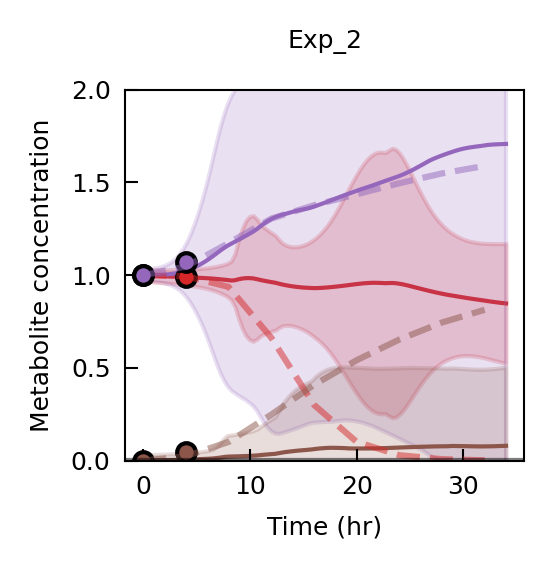

Total parameters: 400
Epoch 0, RMSE: 0.112
Epoch 10, RMSE: 0.111
Epoch 20, RMSE: 0.109
Epoch 30, RMSE: 0.107
Epoch 40, RMSE: 0.104
Epoch 50, RMSE: 0.099
Epoch 60, RMSE: 0.091
Epoch 70, RMSE: 0.080
Epoch 80, RMSE: 0.067
Epoch 90, RMSE: 0.059
Epoch 100, RMSE: 0.053
Epoch 110, RMSE: 0.049
Epoch 120, RMSE: 0.047
Epoch 130, RMSE: 0.045
Epoch 140, RMSE: 0.043
Epoch 150, RMSE: 0.042
Epoch 160, RMSE: 0.040
Epoch 170, RMSE: 0.039
Epoch 180, RMSE: 0.038
Epoch 190, RMSE: 0.036
Epoch 200, RMSE: 0.035
Epoch 210, RMSE: 0.034
Epoch 220, RMSE: 0.032
Epoch 230, RMSE: 0.031
Epoch 240, RMSE: 0.030
Epoch 250, RMSE: 0.028
Epoch 260, RMSE: 0.027
Epoch 270, RMSE: 0.025
Epoch 280, RMSE: 0.024
Epoch 290, RMSE: 0.022
Epoch 300, RMSE: 0.021
Epoch 310, RMSE: 0.019
Epoch 320, RMSE: 0.018
Epoch 330, RMSE: 0.017
Epoch 340, RMSE: 0.016
Epoch 350, RMSE: 0.015
Epoch 360, RMSE: 0.014
Epoch 370, RMSE: 0.014
Epoch 380, RMSE: 0.014
Epoch 390, RMSE: 0.013
Epoch 400, RMSE: 0.014
Epoch 410, RMSE: 0.013
Epoch 420, RMSE: 0.013


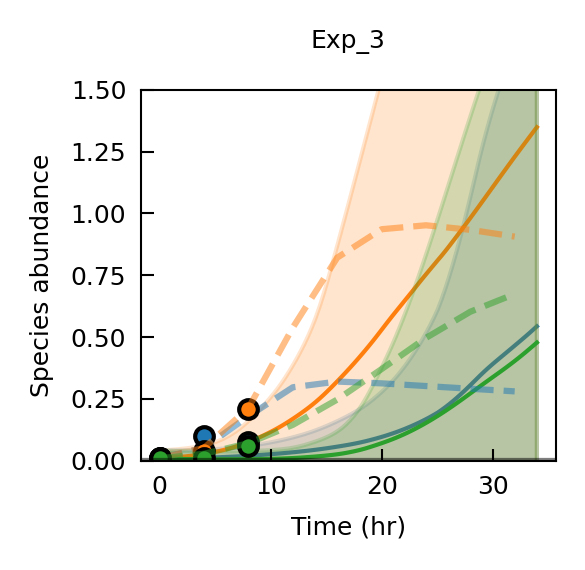

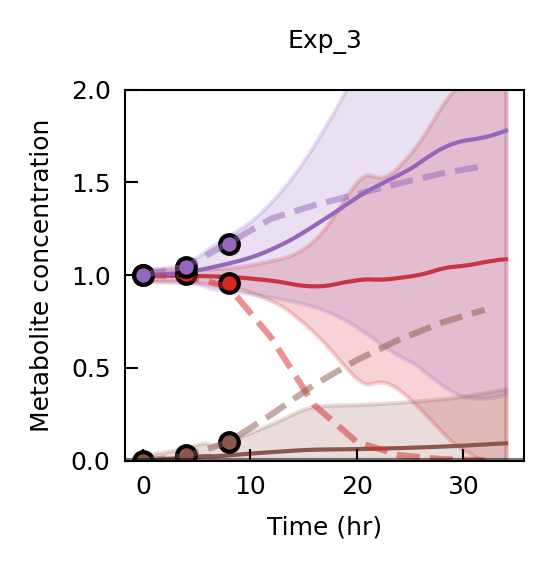

Total parameters: 400
Epoch 0, RMSE: 0.202
Epoch 10, RMSE: 0.200
Epoch 20, RMSE: 0.196
Epoch 30, RMSE: 0.188
Epoch 40, RMSE: 0.172
Epoch 50, RMSE: 0.136
Epoch 60, RMSE: 0.096
Epoch 70, RMSE: 0.082
Epoch 80, RMSE: 0.074
Epoch 90, RMSE: 0.068
Epoch 100, RMSE: 0.063
Epoch 110, RMSE: 0.059
Epoch 120, RMSE: 0.056
Epoch 130, RMSE: 0.053
Epoch 140, RMSE: 0.050
Epoch 150, RMSE: 0.046
Epoch 160, RMSE: 0.043
Epoch 170, RMSE: 0.040
Epoch 180, RMSE: 0.037
Epoch 190, RMSE: 0.034
Epoch 200, RMSE: 0.032
Epoch 210, RMSE: 0.029
Epoch 220, RMSE: 0.027
Epoch 230, RMSE: 0.026
Epoch 240, RMSE: 0.026
Epoch 250, RMSE: 0.025
Epoch 260, RMSE: 0.024
Epoch 270, RMSE: 0.024
Epoch 280, RMSE: 0.024
Epoch 290, RMSE: 0.023
Epoch 300, RMSE: 0.023
Epoch 310, RMSE: 0.023
Epoch 320, RMSE: 0.023
Epoch 330, RMSE: 0.022
Epoch 340, RMSE: 0.022
Epoch 350, RMSE: 0.023
Epoch 360, RMSE: 0.022
Epoch 370, RMSE: 0.022
Epoch 380, RMSE: 0.021
Epoch 390, RMSE: 0.022
Epoch 400, RMSE: 0.021
Epoch 410, RMSE: 0.022
Epoch 420, RMSE: 0.021


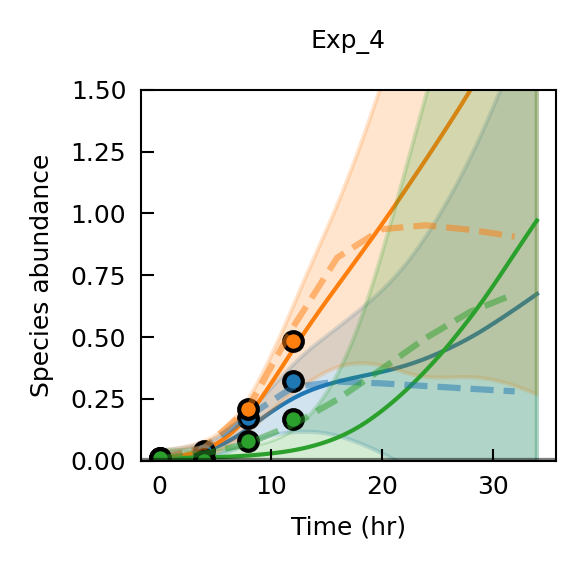

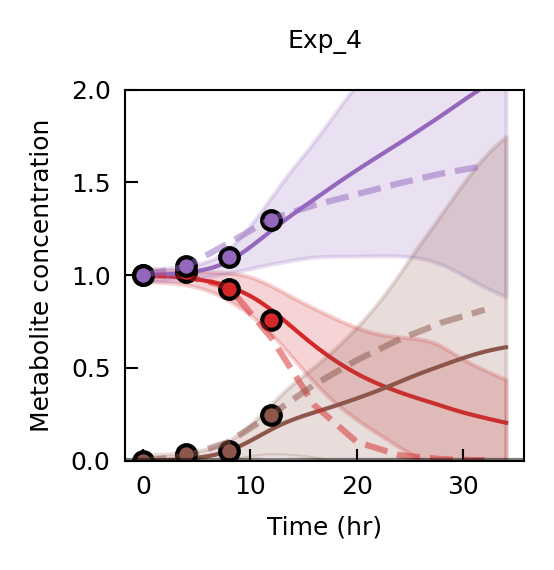

Total parameters: 400
Epoch 0, RMSE: 0.284
Epoch 10, RMSE: 0.280
Epoch 20, RMSE: 0.271
Epoch 30, RMSE: 0.246
Epoch 40, RMSE: 0.181
Epoch 50, RMSE: 0.152
Epoch 60, RMSE: 0.140
Epoch 70, RMSE: 0.131
Epoch 80, RMSE: 0.123
Epoch 90, RMSE: 0.117
Epoch 100, RMSE: 0.112
Epoch 110, RMSE: 0.107
Epoch 120, RMSE: 0.102
Epoch 130, RMSE: 0.098
Epoch 140, RMSE: 0.094
Epoch 150, RMSE: 0.089
Epoch 160, RMSE: 0.085
Epoch 170, RMSE: 0.081
Epoch 180, RMSE: 0.076
Epoch 190, RMSE: 0.072
Epoch 200, RMSE: 0.068
Epoch 210, RMSE: 0.065
Epoch 220, RMSE: 0.062
Epoch 230, RMSE: 0.059
Epoch 240, RMSE: 0.057
Epoch 250, RMSE: 0.055
Epoch 260, RMSE: 0.053
Epoch 270, RMSE: 0.052
Epoch 280, RMSE: 0.051
Epoch 290, RMSE: 0.049
Epoch 300, RMSE: 0.047
Epoch 310, RMSE: 0.046
Epoch 320, RMSE: 0.045
Epoch 330, RMSE: 0.045
Epoch 340, RMSE: 0.044
Epoch 350, RMSE: 0.043
Epoch 360, RMSE: 0.042
Epoch 370, RMSE: 0.041
Epoch 380, RMSE: 0.041
Epoch 390, RMSE: 0.040
Epoch 400, RMSE: 0.040
Epoch 410, RMSE: 0.039
Epoch 420, RMSE: 0.039


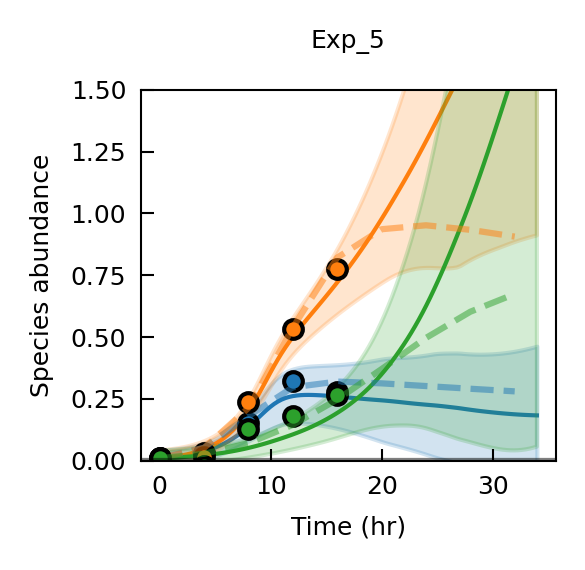

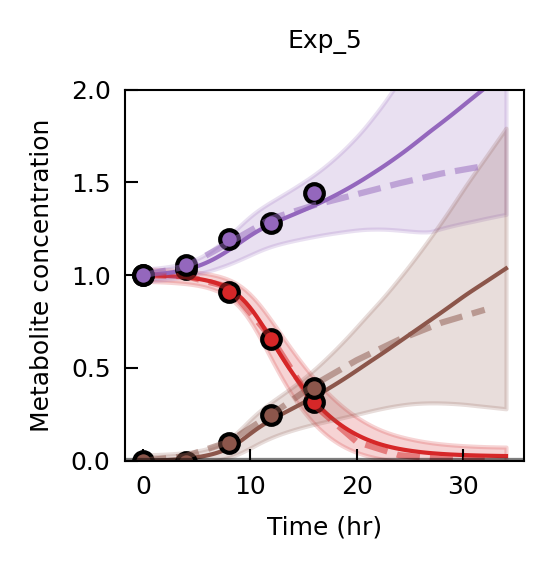

Total parameters: 400
Epoch 0, RMSE: 0.342
Epoch 10, RMSE: 0.335
Epoch 20, RMSE: 0.312
Epoch 30, RMSE: 0.228
Epoch 40, RMSE: 0.198
Epoch 50, RMSE: 0.182
Epoch 60, RMSE: 0.170
Epoch 70, RMSE: 0.160
Epoch 80, RMSE: 0.151
Epoch 90, RMSE: 0.144
Epoch 100, RMSE: 0.137
Epoch 110, RMSE: 0.131
Epoch 120, RMSE: 0.126
Epoch 130, RMSE: 0.120
Epoch 140, RMSE: 0.115
Epoch 150, RMSE: 0.110
Epoch 160, RMSE: 0.105
Epoch 170, RMSE: 0.100
Epoch 180, RMSE: 0.096
Epoch 190, RMSE: 0.091
Epoch 200, RMSE: 0.088
Epoch 210, RMSE: 0.084
Epoch 220, RMSE: 0.081
Epoch 230, RMSE: 0.077
Epoch 240, RMSE: 0.074
Epoch 250, RMSE: 0.071
Epoch 260, RMSE: 0.068
Epoch 270, RMSE: 0.066
Epoch 280, RMSE: 0.064
Epoch 290, RMSE: 0.062
Epoch 300, RMSE: 0.060
Epoch 310, RMSE: 0.059
Epoch 320, RMSE: 0.058
Epoch 330, RMSE: 0.057
Epoch 340, RMSE: 0.056
Epoch 350, RMSE: 0.055
Epoch 360, RMSE: 0.054
Epoch 370, RMSE: 0.053
Epoch 380, RMSE: 0.052
Epoch 390, RMSE: 0.051
Epoch 400, RMSE: 0.051
Epoch 410, RMSE: 0.050
Epoch 420, RMSE: 0.049


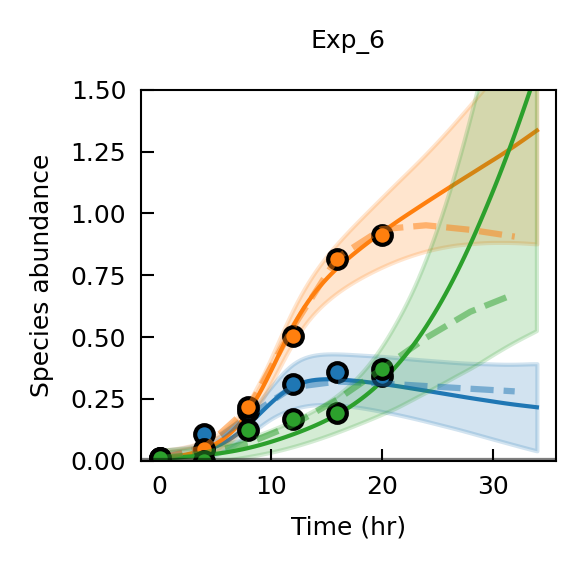

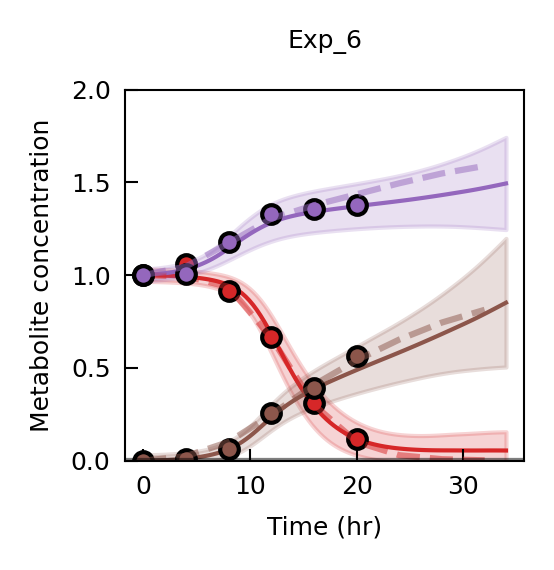

Total parameters: 400
Epoch 0, RMSE: 0.388
Epoch 10, RMSE: 0.376
Epoch 20, RMSE: 0.320
Epoch 30, RMSE: 0.255
Epoch 40, RMSE: 0.237
Epoch 50, RMSE: 0.221
Epoch 60, RMSE: 0.209
Epoch 70, RMSE: 0.198
Epoch 80, RMSE: 0.188
Epoch 90, RMSE: 0.180
Epoch 100, RMSE: 0.172
Epoch 110, RMSE: 0.164
Epoch 120, RMSE: 0.156
Epoch 130, RMSE: 0.148
Epoch 140, RMSE: 0.140
Epoch 150, RMSE: 0.132
Epoch 160, RMSE: 0.124
Epoch 170, RMSE: 0.116
Epoch 180, RMSE: 0.108
Epoch 190, RMSE: 0.099
Epoch 200, RMSE: 0.090
Epoch 210, RMSE: 0.083
Epoch 220, RMSE: 0.078
Epoch 230, RMSE: 0.074
Epoch 240, RMSE: 0.071
Epoch 250, RMSE: 0.069
Epoch 260, RMSE: 0.067
Epoch 270, RMSE: 0.066
Epoch 280, RMSE: 0.064
Epoch 290, RMSE: 0.063
Epoch 300, RMSE: 0.062
Epoch 310, RMSE: 0.061
Epoch 320, RMSE: 0.060
Epoch 330, RMSE: 0.059
Epoch 340, RMSE: 0.058
Epoch 350, RMSE: 0.057
Epoch 360, RMSE: 0.056
Epoch 370, RMSE: 0.056
Epoch 380, RMSE: 0.055
Epoch 390, RMSE: 0.054
Epoch 400, RMSE: 0.054
Epoch 410, RMSE: 0.053
Epoch 420, RMSE: 0.052


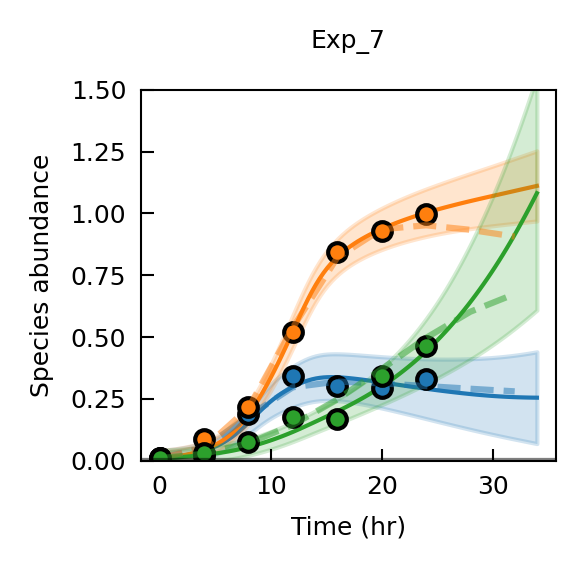

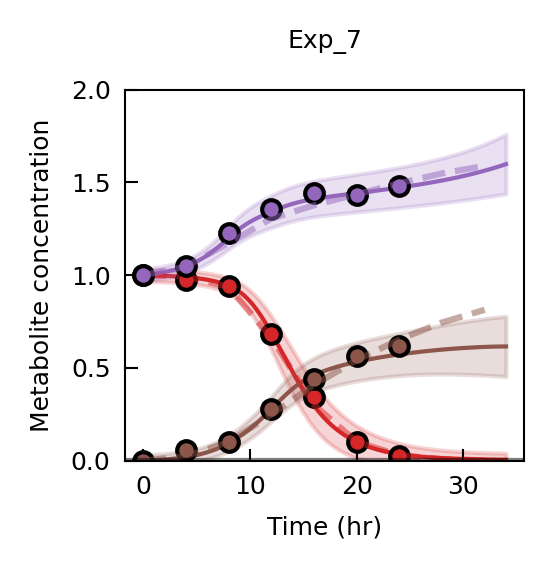

Total parameters: 400
Epoch 0, RMSE: 0.416
Epoch 10, RMSE: 0.397
Epoch 20, RMSE: 0.310
Epoch 30, RMSE: 0.285
Epoch 40, RMSE: 0.267
Epoch 50, RMSE: 0.252
Epoch 60, RMSE: 0.237
Epoch 70, RMSE: 0.225
Epoch 80, RMSE: 0.214
Epoch 90, RMSE: 0.205
Epoch 100, RMSE: 0.196
Epoch 110, RMSE: 0.187
Epoch 120, RMSE: 0.178
Epoch 130, RMSE: 0.170
Epoch 140, RMSE: 0.161
Epoch 150, RMSE: 0.153
Epoch 160, RMSE: 0.143
Epoch 170, RMSE: 0.133
Epoch 180, RMSE: 0.123
Epoch 190, RMSE: 0.113
Epoch 200, RMSE: 0.104
Epoch 210, RMSE: 0.098
Epoch 220, RMSE: 0.091
Epoch 230, RMSE: 0.088
Epoch 240, RMSE: 0.084
Epoch 250, RMSE: 0.082
Epoch 260, RMSE: 0.081
Epoch 270, RMSE: 0.079
Epoch 280, RMSE: 0.078
Epoch 290, RMSE: 0.076
Epoch 300, RMSE: 0.075
Epoch 310, RMSE: 0.074
Epoch 320, RMSE: 0.073
Epoch 330, RMSE: 0.072
Epoch 340, RMSE: 0.071
Epoch 350, RMSE: 0.070
Epoch 360, RMSE: 0.069
Epoch 370, RMSE: 0.068
Epoch 380, RMSE: 0.067
Epoch 390, RMSE: 0.066
Epoch 400, RMSE: 0.065
Epoch 410, RMSE: 0.064
Epoch 420, RMSE: 0.063


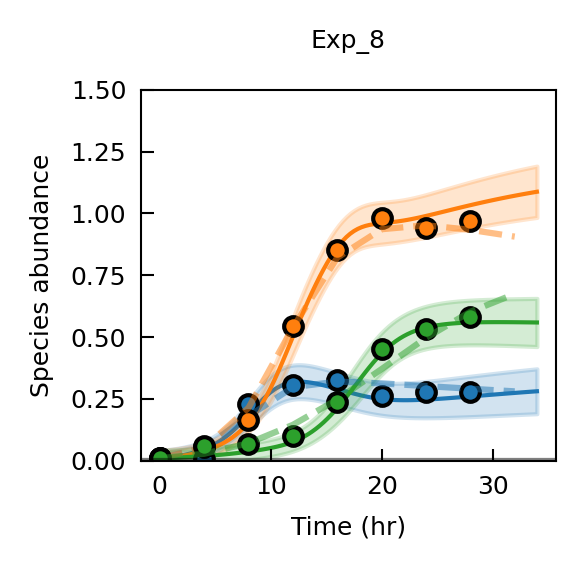

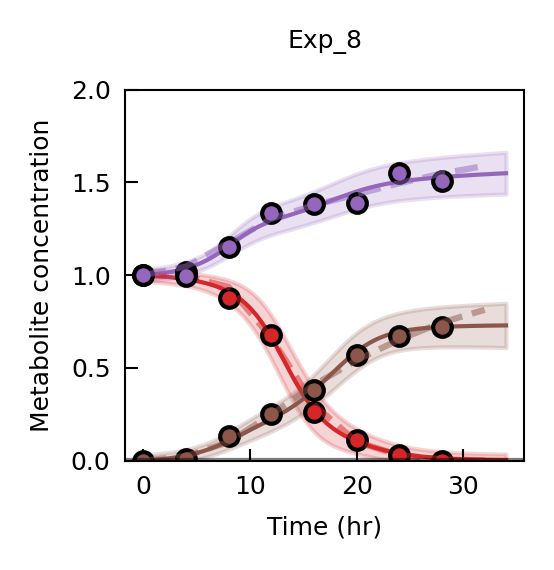

Total parameters: 400
Epoch 0, RMSE: 0.439
Epoch 10, RMSE: 0.411
Epoch 20, RMSE: 0.331
Epoch 30, RMSE: 0.309
Epoch 40, RMSE: 0.289
Epoch 50, RMSE: 0.272
Epoch 60, RMSE: 0.255
Epoch 70, RMSE: 0.241
Epoch 80, RMSE: 0.229
Epoch 90, RMSE: 0.218
Epoch 100, RMSE: 0.207
Epoch 110, RMSE: 0.197
Epoch 120, RMSE: 0.186
Epoch 130, RMSE: 0.175
Epoch 140, RMSE: 0.163
Epoch 150, RMSE: 0.151
Epoch 160, RMSE: 0.140
Epoch 170, RMSE: 0.129
Epoch 180, RMSE: 0.118
Epoch 190, RMSE: 0.110
Epoch 200, RMSE: 0.104
Epoch 210, RMSE: 0.099
Epoch 220, RMSE: 0.096
Epoch 230, RMSE: 0.094
Epoch 240, RMSE: 0.091
Epoch 250, RMSE: 0.089
Epoch 260, RMSE: 0.088
Epoch 270, RMSE: 0.086
Epoch 280, RMSE: 0.084
Epoch 290, RMSE: 0.082
Epoch 300, RMSE: 0.080
Epoch 310, RMSE: 0.078
Epoch 320, RMSE: 0.077
Epoch 330, RMSE: 0.075
Epoch 340, RMSE: 0.073
Epoch 350, RMSE: 0.072
Epoch 360, RMSE: 0.070
Epoch 370, RMSE: 0.068
Epoch 380, RMSE: 0.067
Epoch 390, RMSE: 0.065
Epoch 400, RMSE: 0.063
Epoch 410, RMSE: 0.062
Epoch 420, RMSE: 0.060


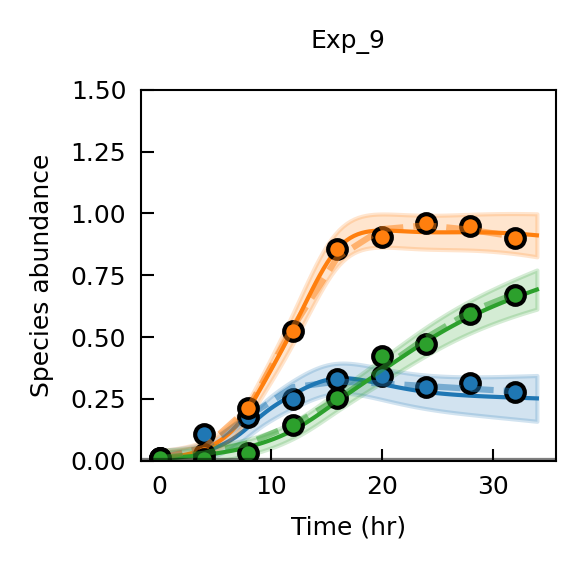

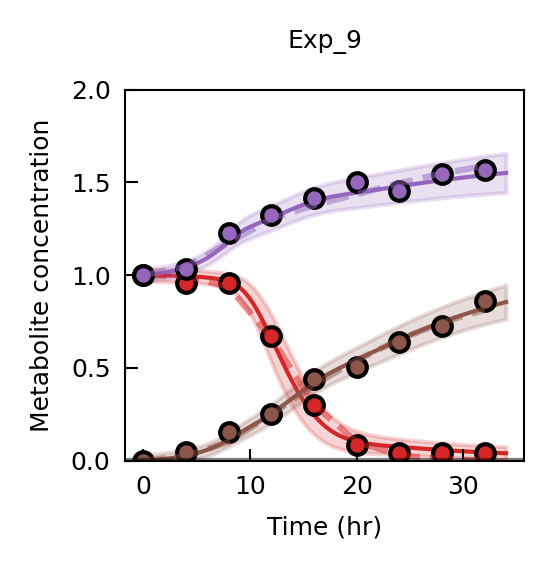

In [7]:
for exp_name, df_train in df.groupby('Treatments'):

    # init model 
    model = NSM(dataframe=df_train, 
                species=species,
                mediators=mediators, 
                inputs=inputs,
                n_hidden=16, n_layers=1,
                nu2=.001, sigma2=0.0001, scale=False)

    # init params
    model.init_params(sample=True, alpha_0=.001, z_std_scale=.01)

    print(f"Total parameters: {model.n_params}")
    t0 = time.time()
    model.fit_rmse(epochs=5000)
    model.fit_posterior(lr=1e-3, n_sample=3)
    print("Elapsed time: {:.3f}s".format(time.time()-t0))

    plot_sample(model, df_test, df_train)